# 2.1 Dataset

In [3]:
%%capture
%pip install numpy
%pip install pandas
%pip install matplotlib.pyplot
%pip install python-terrier

In [4]:
# Top-level imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyterrier as pt

In [5]:
# import docs
base = 'https://raw.githubusercontent.com/Legenden84/search-engines/master/project_handout/lab_files'

docs    = pd.read_json(f'{base}/docs2.jsonl', lines=True, dtype={'docno': str})
queries = pd.read_csv(f'{base}/train_queries.csv')
qrels   = pd.read_csv(f'{base}/train_qrels.csv')

In [6]:
print(docs.shape)
docs.sample(5, random_state=42)

(151993, 2)


,docno,text
114980,D114980,Leaning Tower of Pisa The tower's tilt began d...
88715,D88715,Under the Dome (novel) The semi-organized resi...
38065,D38065,"The First Time Ever I Saw Your Face ""The First..."
16042,D16042,Pretty Little Liars Virtually all these locati...
49231,D49231,"I Say a Little Prayer ""I Say a Little Prayer"" ..."


In [7]:
print(queries.shape)
queries.sample(5)

(10000, 2)


,qid,text
629,629,what is the busiest hurricane season on record
1993,1993,where does at sixes and sevens come from
9072,9072,what's the difference between resident evil 7 ...
2151,2151,where did the nyc tree come from this year
5210,5210,is the metro silver line a bus or train


In [8]:
print(qrels.shape)
qrels.sample(5)

(17746, 4)


,qid,docno,relevance,iteration
9760,3958,D84574,1,0
5497,9719,D48026,1,0
4163,104,D36129,1,0
15409,6296,D132076,2,0
1576,8625,D13984,1,0


In [9]:
print('Unique labels: \n', qrels['relevance'].unique())
print('\n')
print('Distribution of labels: \n', qrels[['qid','relevance']].groupby(by='relevance').count().reset_index())

Unique labels: 
 [2 1]


Distribution of labels: 
    relevance    qid
0          1   7746
1          2  10000


In [10]:
print(qrels[qrels['relevance'] == 2])

        qid    docno  relevance  iteration
0       312      D15          2          0
1      6746      D31          2          0
2       272      D34          2          0
4      5963      D81          2          0
5      7532      D82          2          0
...     ...      ...        ...        ...
17739  1662  D151933          2          0
17740  4884  D151939          2          0
17742  2052  D151960          2          0
17744  3489  D151981          2          0
17745  4835  D151987          2          0

[10000 rows x 4 columns]


In [11]:
qid = 8030

# Sneak peak into the query for qid D127677
qrels_for_qid = qrels[qrels['qid'] == qid]
print(qrels_for_qid)

# Sneak peak into document highly relevant for qid D127677
print('\nQuery')
print(queries.loc[queries['qid'] == qid, 'text'].iloc[0])

# Sneak peak into document somwwhat relevant for qid D127677
docno = qrels_for_qid.sort_values('relevance', ascending=False)['docno'].iloc[0]

print(f'\nRelevant document for qid {qid}: {docno}')
print(docs.loc[docs["docno"] == docno, "text"].iloc[0])

        qid    docno  relevance  iteration
14880  8030  D127677          2          0

Query
what was the first hotel casino in las vegas

Relevant document for qid 8030: D127677
Prem Ratan Dhan Payo Prem Ratan Dhan Payo (English: Found a Treasure Called Love) is a 2015 Indian romantic drama film[4] written and directed by Sooraj Barjatya, produced by Rajshri Productions and distributed by Fox Star Studios. It stars Salman Khan and Sonam Kapoor in lead roles.[5] This is the fourth collaboration between Barjatya and Khan after their previous films Maine Pyar Kiya, Hum Aapke Hain Koun..!, and Hum Saath Saath Hain.


In [12]:
# Statistics
doc_lengths = docs["text"].str.split().str.len()
query_lengths = queries["text"].str.split().str.len()

res = pd.DataFrame({
    "min": [query_lengths.min(), doc_lengths.min()],
    "max": [query_lengths.max(), doc_lengths.max()],
    "median": [query_lengths.median(), doc_lengths.median()],
    "average": [query_lengths.mean(), doc_lengths.mean()]
}, index=["queries", "documents"])

res

,min,max,median,average
queries,5,23,9.0,9.080600
documents,1,2219,82.0,91.458784


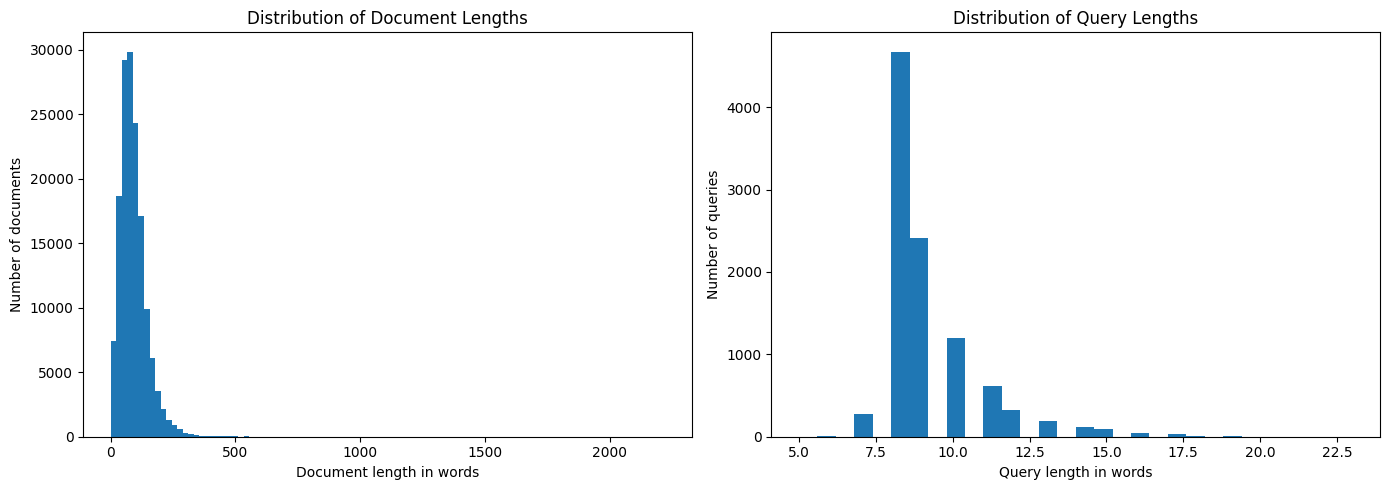

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Document length distribution
axes[0].hist(doc_lengths, bins=100)
axes[0].set_title("Distribution of Document Lengths")
axes[0].set_xlabel("Document length in words")
axes[0].set_ylabel("Number of documents")

# Query length distribution
axes[1].hist(query_lengths, bins=30)
axes[1].set_title("Distribution of Query Lengths")
axes[1].set_xlabel("Query length in words")
axes[1].set_ylabel("Number of queries")

plt.tight_layout()
plt.show()

# 2.2 Indexing

In [14]:
# Load java
!curl -s "https://get.sdkman.io" | bash && source "$HOME/.sdkman/bin/sdkman-init.sh" && sdk install java 11.0.22-amzn < /dev/null


                                -+syyyyyyys:
                            `/yho:`       -yd.
                         `/yh/`             +m.
                       .oho.                 hy                          .`
                     .sh/`                   :N`                `-/o`  `+dyyo:.
                   .yh:`                     `M-          `-/osysoym  :hs` `-+sys:      hhyssssssssy+
                 .sh:`                       `N:          ms/-``  yy.yh-      -hy.    `.N-````````+N.
               `od/`                         `N-       -/oM-      ddd+`     `sd:     hNNm        -N:
              :do`                           .M.       dMMM-     `ms.      /d+`     `NMMs       `do
            .yy-                             :N`    ```mMMM.      -      -hy.       /MMM:       yh
          `+d+`           `:/oo/`       `-/osyh/ossssssdNMM`           .sh:         yMMN`      /m.
         -dh-           :ymNMMMMy  `-/shmNm-`:N/-.``   `.sN            /N-         `NMMy      .m/
  

In [15]:
!which java
!java -version
!readlink -f $(which java)

!ls -la /usr/lib/jvm

/usr/bin/java
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
/usr/lib/jvm/java-17-openjdk-amd64/bin/java
total 16
drwxr-xr-x 3 root root 4096 Apr  2 13:13 .
drwxr-xr-x 1 root root 4096 Apr  2 13:13 ..
lrwxrwxrwx 1 root root   21 Jan 29 03:35 java-1.17.0-openjdk-amd64 -> java-17-openjdk-amd64
-rw-r--r-- 1 root root 1773 Jan 29 03:35 .java-1.17.0-openjdk-amd64.jinfo
drwxr-xr-x 9 root root 4096 Apr  2 13:13 java-17-openjdk-amd64


In [16]:
# test java env
!java --version
!javac --version

openjdk 17.0.18 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
javac 17.0.18


In [17]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

In [18]:
import pyterrier as pt
if not pt.started():
    pt.init()

print("JAVA_HOME:", os.environ["JAVA_HOME"])
print("Java started:", pt.java.started())

/tmp/ipykernel_2040/4071291109.py:2: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done
JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
Java started: True


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_2040/4071291109.py:3: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


# PyTerrier

In [19]:
indexer = pt.IterDictIndexer("./indexes/default", overwrite=True)
index_ref = indexer.index(docs.to_dict(orient='records'))
index_ref.toString()

'./indexes/default/data.properties'

In [ ]:
index = pt.IndexFactory.of(index_ref)
print(index.getCollectionStatistics().toString())

Number of documents: 151993
Number of terms: 124533
Number of postings: 6389931
Number of fields: 0
Number of tokens: 8423338
Field names: []
Positions:   false

